In [1]:
import requests
import io
import pandas as pd
import geopandas as gpd
import city2graph as c2g
import osmnx as ox
import folium

c:\Users\aloac\repositorios\procesos_SIG\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Ejemplo usando datos del General Transit Feed Specification (GTFS)

In [ ]:
# url para descargar datos
gtfs_url = "https://static.opendata.metlink.org.nz/v1/gtfs/full.zip"
# Descargar y cargar GTFS
gtfs = c2g.load_gtfs(io.BytesIO(requests.get(gtfs_url).content))


In [4]:
gtfs

{'agency':    agency_id                           agency_name  \
 0       MADG              Madge Coachlines Limited   
 1        UZM                                Uzabus   
 2        NCE   New Zealand Coach Services (Exempt)   
 3        NBM                                NZ Bus   
 4       WCCL                  Wellington Cable Car   
 5       VLYF                          Valley Flyer   
 6        TZM                    Tranzit Coachlines   
 7        MNM           Mana Coach Services Limited   
 8       RAIL                          Metlink Rail   
 9       CLSC                       Classic Coaches   
 10       NBE                       NZ Bus (Exempt)   
 11      PTXL             Paraparaumu Taxis Limited   
 12       TZE           Tranzit Coachlines (Exempt)   
 13      RUNC              Runcimans Motors Limited   
 14       GOW                         Go Wellington   
 15       MLO                                 Other   
 16       HRC             Horizons Regional Council   


In [24]:

# Seleccionar ruta y dirección
route = "7"
direction = "1"
# Obtener route_id
route_id = (
  gtfs["routes"]
  .query("route_short_name == @route")
  .route_id
  .iloc[0]
)
print(route_id)
# Obtener trip_ids para la ruta y dirección seleccionadas
trip_ids = (
  gtfs["trips"]
  .query("route_id == @route_id & direction_id == @direction")
  .sort_values(["service_id", "trip_id"])
  .loc[:, ["trip_id"]]
)
print("Número de viajes para la ruta y dirección seleccionadas:")
print(trip_ids.shape[0])
trip_ids.head()

70
Número de viajes para la ruta y dirección seleccionadas:
152


,trip_id
317,7__1__700__TZM__102__102_20251221
5097,7__1__100__TZM__102__6__102__6_20251221
9742,7__1__116__TZM__102__6__102__6_20251221
4261,7__1__400__TZM__103__3__103__3_20251221
7117,7__1__450__TZM__103__3__103__3_20251221


In [12]:
# Obtener stop_times para el primer trip_id
trip_id = trip_ids.trip_id.iloc[0]
stop_times = (
  gtfs["stop_times"]
  .query("trip_id == @trip_id")
  .loc[:, ["trip_id", "stop_id", "arrival_time"]]
  .sort_values("trip_id")
)
stop_times.head()

,trip_id,stop_id,arrival_time
9560,7__1__700__TZM__102__102_20251221,7730,07:35:00
9582,7__1__700__TZM__102__102_20251221,5012,07:54:24
9581,7__1__700__TZM__102__102_20251221,5010,07:53:51
9580,7__1__700__TZM__102__102_20251221,5008,07:52:27
9579,7__1__700__TZM__102__102_20251221,7708,07:50:55


In [45]:
# Calcular tiempo restante hasta las 08:05:00
end_time = pd.to_datetime("08:05:00", format = "%X")
print(end_time)

times_remaining = (
  stop_times
  .assign(
    time_remaining = (
      end_time - pd.to_datetime(stop_times.arrival_time, format = "%X"))
      .dt.seconds)
  .loc[:, ["stop_id", "arrival_time","time_remaining"]]
)
times_remaining.head(15)

1900-01-01 08:05:00


,stop_id,arrival_time,time_remaining
9560,7730,07:35:00,1800
9582,5012,07:54:24,636
9581,5010,07:53:51,669
9580,5008,07:52:27,753
9579,7708,07:50:55,845
9578,7709,07:49:59,901
9577,7711,07:48:19,1001
9576,7712,07:47:04,1076
9575,7713,07:46:24,1116
9574,7714,07:45:04,1196


In [46]:
# Unir con la tabla de paradas y crear burbujas
route_stops = (
  gtfs["stops"]
  .merge(times_remaining)
)
route_stops.head()


,stop_id,stop_code,stop_name,stop_desc,stop_lat,stop_lon,zone_id,stop_url,location_type,parent_station,stop_timezone,geometry,arrival_time,time_remaining
0,7729,7729,Quebec Street at Baffin Grove,NaN,-41.320980,174.763569,2,NaN,0,NaN,Pacific/Auckland,POINT (174.76357 -41.32098),07:35:40,1760
1,7700,7700,Brooklyn - Stop A,NaN,-41.305033,174.765401,2,NaN,0,NaN,Pacific/Auckland,POINT (174.7654 -41.30503),07:40:00,1500
2,5012,5012,Lambton Central - Stop A,NaN,-41.282666,174.775666,1,NaN,0,NaN,Pacific/Auckland,POINT (174.77567 -41.28267),07:54:24,636
3,7713,7713,Brooklyn Road at Central Park,NaN,-41.298385,174.768573,1,NaN,0,NaN,Pacific/Auckland,POINT (174.76857 -41.29839),07:46:24,1116
4,5016,5016,Wellington Station - Stop E,NaN,-41.278431,174.778916,1,NaN,0,NaN,Pacific/Auckland,POINT (174.77892 -41.27843),07:57:00,480


In [47]:
route_stops['time_remaining'].describe()

count      25.000000
mean     1242.760000
std       413.284535
min       480.000000
25%       901.000000
50%      1340.000000
75%      1584.000000
max      1800.000000
Name: time_remaining, dtype: float64

<Axes: >

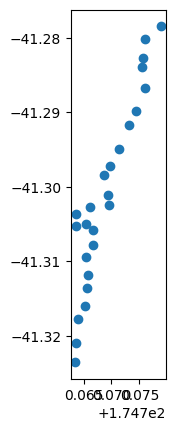

In [48]:
route_stops.plot()

In [51]:
# Crear burbujas de isocronas
bubbles = [s.buffer(d)
           for s, d in zip(route_stops.geometry.to_crs(2193),
                           route_stops.time_remaining)]

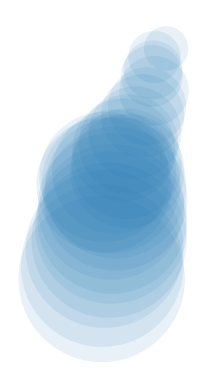

In [52]:
# Crear GeoDataFrame de burbujas
isochrone_bubbles = gpd.GeoDataFrame(
  geometry = gpd.GeoSeries(bubbles), crs = 2193)

isochrone_bubbles.plot(alpha = 0.1).set_axis_off()

In [29]:
# Descargar grafo de calles para el área de las isocronas
bb = [float(x) 
      for x in isochrone_bubbles.to_crs(4326).total_bounds]
print(bb)
# Crear grafo de calles
G = ox.graph.graph_from_bbox(bb, network_type = "walk", 
                             simplify = False)

[174.74202159376182, -41.33979901563883, 174.78528892334427, -41.274109146720185]


In [30]:
# Encontrar nodos más cercanos a las paradas de la ruta
nearest_nodes = ox.distance.nearest_nodes(G,
  [p.x for p in route_stops.geometry],
  [p.y for p in route_stops.geometry])
nearest_nodes

array([13415527777, 13415528244,  2672451736, 13415527562, 13417294288,
       13417294308, 13417294340, 13417294374, 13417294706,   172820673,
        4147685897,  5645000926,   172497203, 13431596246,   172497151,
       13253580883, 13287379979,  4294151473, 13431588597,   271586803,
        6036541490, 12964476644, 12964498614,  5681335066, 12522768187])

In [37]:
route_stops.dtypes

stop_id             object
stop_code           object
stop_name           object
stop_desc           object
stop_lat           float64
stop_lon           float64
zone_id             object
stop_url            object
location_type       object
parent_station      object
stop_timezone       object
geometry          geometry
time_remaining       int32
dtype: object

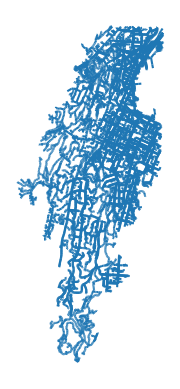

In [53]:
# Crear isocronas basadas en las calles

isochrone_streets = (
  gpd.GeoDataFrame(
    geometry = gpd.GeoSeries(pd.concat([
      ox.convert.graph_to_gdfs(
        ox.truncate.truncate_graph_dist(G, node, dist), 
        nodes = False).geometry
      for node, dist in zip(
        nearest_nodes,
        route_stops.time_remaining)]).union_all(),
    crs = 4326)
  ).to_crs(2193)
)
isochrone_streets.plot().set_axis_off()

In [22]:
isochrone_approx = (
  isochrone_streets
  .concave_hull(ratio = 0.05)
)

In [23]:
m = folium.Map(
  tiles = None,
  zoom_start = 13, max_bounds = True,
  location = [(bb[0] + bb[2]) / 2, (bb[1] + bb[3]) / 2],
  min_lon = bb[0], min_lat = bb[1], 
  max_lon = bb[2], max_lat = bb[3]
)

folium.TileLayer("CartoDB Positron", overlay = True).add_to(m)

isochrone_bubbles.explore(
  m = m, name = "Walk time circles", tooltip = False,
  style_kwds = dict(fill = False, color = "black", weight = 0.35))

isochrone_approx.explore(
  m = m, name = "Approximate isochrone", tooltip = False,
  style_kwds = dict(color = "red", fill = False, weight = 3))

isochrone_streets.explore(
  m = m, name = "Streets isochrone", tooltip = False,
  style_kwds = dict(color = "orange", weight = 1))

route_stops.explore(
  m = m, name = "Stops", tooltip = "stop_name",
  style_kwds = dict(color = "red", fill = False, radius = 6))

folium.LayerControl().add_to(m)
m